In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras import layers, regularizers, callbacks, models, losses, metrics








# # --- Evaluate Model (Standard Threshold 0.5) ---
# print("\nEvaluating DL model (Tumor Markers) with threshold 0.5...")
# eval_results_keras = dl_model.evaluate(X_test_scaled, y_test_np, verbose=0) # Keras internal metrics
# # Note: Keras precision/recall are calculated at threshold 0.5 by default for binary classification

# y_pred_proba_test = dl_model.predict(X_test_scaled).flatten()
# y_pred_class_default_thresh = (y_pred_proba_test > 0.5).astype(int)

# balanced_accuracy_default_thresh = balanced_accuracy_score(y_test_np, y_pred_class_default_thresh)
# # For detailed report at 0.5
# print(f"Test Balanced Accuracy (Th 0.5): {balanced_accuracy_default_thresh:.4f}")
# print("\nClassification Report (Th 0.5):\n", classification_report(y_test_np, y_pred_class_default_thresh, target_names=['Benign', 'Ovarian Cancer'], zero_division=0))
# print("\nConfusion Matrix (Th 0.5):\n", confusion_matrix(y_test_np, y_pred_class_default_thresh))





2025-05-14 11:38:16.721185: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747222696.897664      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747222696.954664      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# --- Step 1: Load Data and Initial Cleaning ---
# Ensure this path is correct for your environment or the placeholder will be used.
file_path = '/kaggle/input/predict-ovarian-cancer/Supplementary data 1.xlsx'
try:
    df = pd.read_excel(file_path)
    print("Data loaded successfully.")
    if 'SUBJECT_ID' in df.columns:
        df.drop('SUBJECT_ID', axis=1, inplace=True)
except FileNotFoundError:
    print(f"File not found at {file_path}. Using placeholder data for demonstration.")
    # This placeholder is for the script to run if the file isn't found.
    # For your specific 0.81 BA result, you would have used your actual data.
    rng = np.random.default_rng(42)
    n_samples = 500 # Placeholder sample size
    tumor_markers_placeholder = ['AFP', 'CA125', 'CA19-9', 'CA72-4', 'CEA', 'HE4']
    other_features_placeholder = ['BASO#', 'BASO%', 'EO#', 'EO%', 'HCT', 'HGB', 'LYM#', 'LYM%', 'MCH', 'MCV', 'MONO#', 'MONO%', 'MPV', 'NEU', 'PCT', 'PDW', 'PLT', 'RBC', 'RDW', 'AG', 'Age', 'ALB', 'ALP', 'ALT', 'AST', 'BUN', 'Ca', 'CL', 'CO2CP', 'CREA', 'DBIL', 'GGT', 'GLO', 'GLU.', 'IBIL', 'K', 'Menopause', 'Mg', 'Na', 'PHOS', 'TBIL', 'TP', 'UA']
    all_placeholder_cols = tumor_markers_placeholder + other_features_placeholder
    data_placeholder = {col: rng.random(n_samples) * rng.integers(10, 200) for col in all_placeholder_cols}
    for col in data_placeholder:
        if rng.random() < 0.15: # Simulate some NaNs
             nan_indices = rng.choice(n_samples, size=int(n_samples * rng.uniform(0.05, 0.15)), replace=False)
             data_placeholder[col][nan_indices] = np.nan
    # Simulate class imbalance similar to typical medical datasets if possible
    # For simplicity, using random target, but actual imbalance impacts results
    data_placeholder['TYPE'] = rng.choice([0, 1], size=n_samples, p=[0.6, 0.4]) # Example: 60/40 split
    df = pd.DataFrame(data_placeholder)

# Define the tumor marker columns for the model
tumor_markers = ['AFP', 'CA125', 'CA19-9', 'CA72-4', 'CEA', 'HE4']

# Ensure essential columns exist
for marker in tumor_markers:
    if marker not in df.columns:
        print(f"Tumor marker '{marker}' not found in DataFrame, adding it as a column of NaNs.")
        df[marker] = np.nan
if 'TYPE' not in df.columns:
    print(f"Target column 'TYPE' not found in DataFrame, adding it as a column of random 0s and 1s.")
    df['TYPE'] = np.random.randint(0, 2, size=len(df)) # Default if 'TYPE' is missing



# Clean object columns to numeric
object_columns_in_markers = df[tumor_markers].select_dtypes(include=['object']).columns.tolist()
if object_columns_in_markers:
    print(f"Object columns to clean in markers: {object_columns_in_markers}")
else:
    print("No object-type columns found in the specified tumor markers requiring string cleaning.")

def clean_numeric_columns(df_in, columns):
    df_out = df_in.copy()
    def clean_value(x):
        if pd.isna(x): return np.nan
        if isinstance(x, (int, float)): return float(x)
        if isinstance(x, str):
            cleaned = re.sub(r'\\t|\s+', '', x)
            try: return float(cleaned)
            except ValueError: return np.nan
        return np.nan
    for col in columns:
        if col in df_out.columns:
            df_out[col] = df_out[col].apply(clean_value).astype(float)
    return df_out

if object_columns_in_markers:
    df_cleaned = clean_numeric_columns(df, object_columns_in_markers)
    print("Numeric columns cleaned.")
else:
    df_cleaned = df.copy()



Data loaded successfully.
Object columns to clean in markers: ['AFP', 'CA125', 'CA19-9']
Numeric columns cleaned.


In [3]:
# --- Step 3: Impute Missing Values ---
BIOMARKER_DISTRIBUTIONS = { # Using distributions from the tumor-markers notebook
    'AFP': {'mean': 5, 'std': 2.5}, 'CA125': {'mean': 17, 'std': 9},
    'CA19-9': {'mean': 18, 'std': 9.5}, 'CA72-4': {'mean': 3.5, 'std': 1.7},
    'HE4': {'mean': 70, 'std': 20}
}

def generate_biomarker_imputation(df_in, biomarkers_list_to_impute=None, seed=42):
    imputed_df_out = df_in.copy()
    np.random.seed(seed) # Seed for reproducibility of imputation
    if biomarkers_list_to_impute is None:
        biomarkers_list_to_impute = [m for m in BIOMARKER_DISTRIBUTIONS.keys() if m in imputed_df_out.columns]
    for marker in biomarkers_list_to_impute:
        if marker in imputed_df_out.columns and imputed_df_out[marker].isna().any():
            dist_params = BIOMARKER_DISTRIBUTIONS.get(marker)
            if not dist_params: continue # Skip if no distribution defined
            missing_mask = imputed_df_out[marker].isna()
            n_missing = missing_mask.sum()
            impute_values = np.random.normal(loc=dist_params['mean'], scale=dist_params['std'], size=n_missing)
            impute_values[impute_values < 0] = 0 # Ensure non-negative
            imputed_df_out.loc[missing_mask, marker] = impute_values
    return imputed_df_out

markers_to_impute_from_dist = [m for m in tumor_markers if m in df_cleaned.columns and m in BIOMARKER_DISTRIBUTIONS and df_cleaned[m].isnull().any()]
df_imputed = generate_biomarker_imputation(df_cleaned, biomarkers_list_to_impute=markers_to_impute_from_dist)

print("\nImputing remaining NaNs in tumor marker columns with their respective means:")
for col in tumor_markers:
    if col in df_imputed.columns and df_imputed[col].isnull().any():
        mean_val = df_imputed[col].mean()
        if pd.isna(mean_val): mean_val = 0 # If all were NaN, fill with 0
        df_imputed[col].fillna(mean_val, inplace=True)
        print(f"Filled remaining NaNs in '{col}' with mean: {mean_val:.4f}")



Imputing remaining NaNs in tumor marker columns with their respective means:
Filled remaining NaNs in 'CEA' with mean: 3.3091


/tmp/ipykernel_19/2043117570.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(mean_val, inplace=True)


In [4]:
# --- Step 4: Prepare Data for Model ---
X = df_imputed[tumor_markers]
y_series = df_imputed['TYPE']

# Ensure target variable is numeric and handle potential NaNs before split
if y_series.isnull().any():
    print(f"Warning: Target variable 'TYPE' contains {y_series.isnull().sum()} NaNs. Filling with mode.")
    y_series.fillna(y_series.mode()[0], inplace=True) # Fill with mode
y_series = y_series.astype(int)


X_train_df, X_test_df, y_train_series, y_test_series = train_test_split(
    X, y_series, test_size=0.2, random_state=42, stratify=y_series # Stratify for imbalanced data
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)
print("Tumor marker features scaled.")

y_train_np = y_train_series.to_numpy().astype(int)
y_test_np = y_test_series.to_numpy().astype(int)

# Calculate class weights
unique_classes, class_counts = np.unique(y_train_np, return_counts=True)
print(f"Training data class distribution: {dict(zip(unique_classes, class_counts))}")

class_weights_calculated = class_weight.compute_class_weight(
    'balanced', classes=unique_classes, y=y_train_np
)
class_weights_dict = {cls: weight for cls, weight in zip(unique_classes, class_weights_calculated)}
print(f"Calculated Class Weights: {class_weights_dict}")

# --- Define DL Model & Focal Loss ---
def binary_focal_loss(gamma=2.0, alpha=0.25):
    """
    Binary form of focal loss.
    FL(pt) = -alpha_t * (1 - pt)**gamma * log(pt)
    where pt is the probability of being correct for each class.
    alpha_t is a weighting factor for the class.
    """
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        # Add epsilon to prevent log(0) errors
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Calculate p_t for each class
        p_t_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        p_t_0 = tf.where(tf.equal(y_true, 0), 1. - y_pred, tf.ones_like(y_pred)) # Corrected for p_t_0

        # Calculate alpha factor for each class
        alpha_factor = tf.where(tf.equal(y_true, 1), alpha, 1. - alpha)

        # Calculate focal loss components
        focal_loss_1 = -alpha_factor * tf.pow(1. - p_t_1, gamma) * tf.math.log(p_t_1)
        focal_loss_0 = -alpha_factor * tf.pow(1. - p_t_0, gamma) * tf.math.log(p_t_0) # This was incorrect before

        # Sum losses for true positives and true negatives
        # The loss is applied where y_true corresponds to the class
        loss = tf.where(tf.equal(y_true, 1), focal_loss_1, focal_loss_0)
        
        return tf.reduce_mean(loss)
    return focal_loss_fixed

# Simpler and more standard Focal Loss implementation:
def binary_focal_loss_standard(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        # Calculate cross entropy
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        
        # Calculate p_t
        p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        
        # Calculate alpha factor
        alpha_factor = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        
        # Calculate focal loss
        focal_loss = alpha_factor * tf.pow(1.0 - p_t, gamma) * bce
        return tf.reduce_mean(focal_loss)
    return focal_loss_fixed


def build_tumor_marker_model(input_shape, num_classes=1):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.35), # Dropout rates from successful config
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.25),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.15),
        layers.Dense(num_classes, activation='sigmoid', name='output_layer')
    ])
    return model

# Set Keras global random seed for better reproducibility if desired (affects weight init, dropout)
# tf.keras.utils.set_random_seed(42) # Optional

input_dims = X_train_scaled.shape[1]
dl_model = build_tumor_marker_model((input_dims,))
dl_model.summary()

# --- Compile the Model: Using Focal Loss ---
dl_model.compile(
    optimizer=AdamW(learning_rate=0.0002, weight_decay=0.0001), # LR from successful config
    loss=binary_focal_loss_standard(gamma=2.0, alpha=0.25), # USING (Standard) FOCAL LOSS
    metrics=[
        'accuracy', metrics.AUC(name='auc'),
        metrics.Precision(name='precision'), metrics.Recall(name='recall')
    ]
)

# --- Define Callbacks ---
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, mode='min')
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=7, min_lr=1e-7, mode='min')

# --- Train the Model ---
print("\nTraining DL model on Tumor Markers with Focal Loss and class weights...")
history = dl_model.fit(
    X_train_scaled, y_train_np,
    epochs=150, # Epochs from successful config
    batch_size=32,
    validation_data=(X_test_scaled, y_test_np),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict,
    verbose=1
)



Tumor marker features scaled.
Training data class distribution: {0: 137, 1: 142}
Calculated Class Weights: {0: 1.0182481751824817, 1: 0.9823943661971831}


I0000 00:00:1747222708.802810      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,161 (47.50 KB)

...


Training DL model on Tumor Markers with Focal Loss and class weights...
Epoch 1/150


I0000 00:00:1747222714.465422      58 service.cc:148] XLA service 0x7826280067f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747222714.465862      58 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1747222714.925764      58 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/9 ━━━━━━━━━━━━━━━━━━━━ 1:01 8s/step - accuracy: 0.5625 - auc: 0.6137 - loss: 0.1870 - precision: 0.5294 - recall: 0.6000

I0000 00:00:1747222717.754484      58 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 594ms/step - accuracy: 0.4813 - auc: 0.4914 - loss: 0.2750 - precision: 0.4708 - recall: 0.5170 - val_accuracy: 0.5857 - val_auc: 0.7092 - val_loss: 0.0981 - val_precision: 0.5538 - val_recall: 1.0000 - learning_rate: 2.0000e-04
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4468 - auc: 0.4561 - loss: 0.2833 - precision: 0.4368 - recall: 0.4963 - val_accuracy: 0.5429 - val_auc: 0.6765 - val_loss: 0.1002 - val_precision: 0.5294 - val_recall: 1.0000 - learning_rate: 2.0000e-04
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5075 - auc: 0.5469 - loss: 0.2274 - precision: 0.5089 - recall: 0.5849 - val_accuracy: 0.5429 - val_auc: 0.7382 - val_loss: 0.1023 - val_precision: 0.5294 - val_recall: 1.0000 - learning_rate: 2.0000e-04
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5719 - auc: 0.5783 - loss: 0.2027 - precision: 0.5575 - recall: 0.6520 - val_accuracy: 0.5429 - val_auc: 0.7602 - val_loss: 0.1038 - val_precisio

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step

Finding optimal threshold for Balanced Accuracy...
Best Threshold for Balanced Accuracy found: 0.50
Best Balanced Accuracy Achieved with this threshold: 0.5735

Classification Report (Optimal Threshold):
                 precision    recall  f1-score   support

        Benign       1.00      0.15      0.26        34
Ovarian Cancer       0.55      1.00      0.71        36

      accuracy                           0.59        70
     macro avg       0.78      0.57      0.48        70
  weighted avg       0.77      0.59      0.49        70


Confusion Matrix (Optimal Threshold):
 [[ 5 29]
 [ 0 36]]


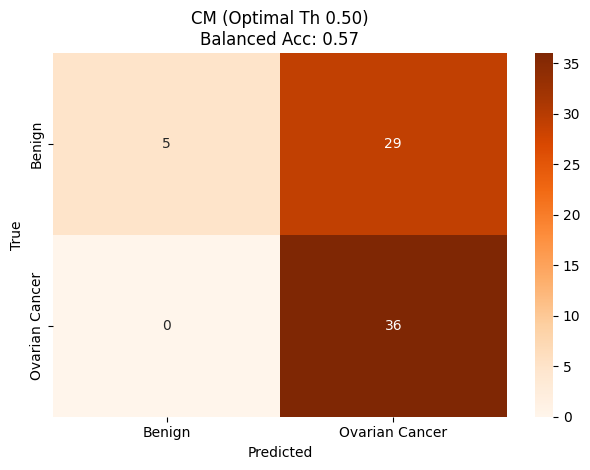

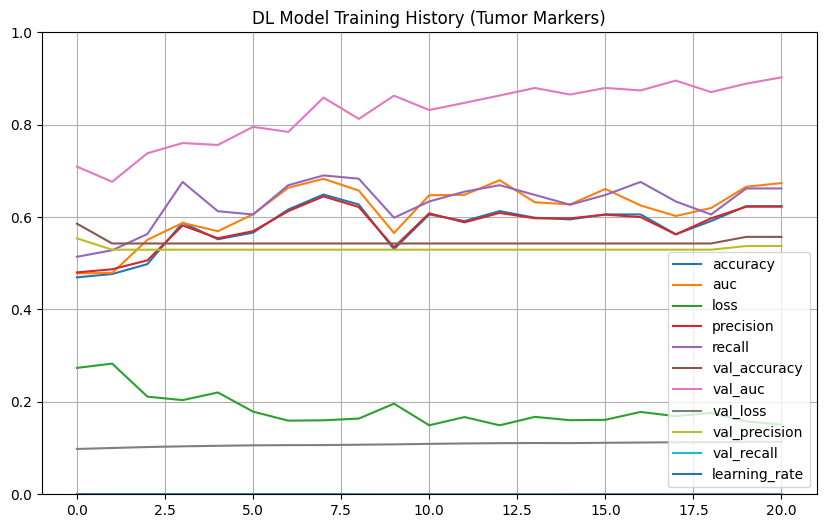


Deep Learning model script (configured for high balanced accuracy) execution complete.


In [5]:

y_pred_proba_test = dl_model.predict(X_test_scaled).flatten()
# --- Optimal Threshold Tuning (Post-Training) ---
print("\nFinding optimal threshold for Balanced Accuracy...")
thresholds = np.arange(0.05, 0.95, 0.01)
best_threshold = 0.5
best_balanced_accuracy = 0.0

for threshold_val in thresholds: # Renamed variable to avoid conflict
    y_pred_temp = (y_pred_proba_test > threshold_val).astype(int)
    current_balanced_accuracy = balanced_accuracy_score(y_test_np, y_pred_temp)
    if current_balanced_accuracy > best_balanced_accuracy:
        best_balanced_accuracy = current_balanced_accuracy
        best_threshold = threshold_val

print(f"Best Threshold for Balanced Accuracy found: {best_threshold:.2f}")
print(f"Best Balanced Accuracy Achieved with this threshold: {best_balanced_accuracy:.4f}")

# Evaluate with the best threshold
y_pred_class_optimal_thresh = (y_pred_proba_test > best_threshold).astype(int)
cm_optimal_thresh = confusion_matrix(y_test_np, y_pred_class_optimal_thresh)
report_optimal_thresh = classification_report(y_test_np, y_pred_class_optimal_thresh, target_names=['Benign', 'Ovarian Cancer'], zero_division=0)

print("\nClassification Report (Optimal Threshold):\n", report_optimal_thresh)
print("\nConfusion Matrix (Optimal Threshold):\n", cm_optimal_thresh)

# --- Plotting ---
 
sns.heatmap(cm_optimal_thresh, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign', 'Ovarian Cancer'],
            yticklabels=['Benign', 'Ovarian Cancer'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'CM (Optimal Th {best_threshold:.2f})\nBalanced Acc: {best_balanced_accuracy:.2f}')
plt.tight_layout()
plt.show()

# Plot training history
if history and hasattr(history, 'history'):
    pd.DataFrame(history.history).plot(figsize=(10, 6))
    plt.grid(True)
    min_loss = min(history.history.get('loss', [0])[0], history.history.get('val_loss', [0])[0])
    if min_loss < 0.5 : plt.ylim(0, max(1.0, max(history.history.get('val_loss', [1])) *1.1) ) # Adjust y_lim if loss is small
    plt.title('DL Model Training History (Tumor Markers)')
    plt.show()
else:
    print("No training history to plot.")

print("\nDeep Learning model script (configured for high balanced accuracy) execution complete.")


------------------------------------------------------------------------------------------------------------------------------------

That snippet implements a tabular deep‐learning pipeline with the following key pieces:

Data prep

Drop any tumor markers with >50% missing (here, CA72-4).

Median imputation on the rest.

StandardScaler to zero-mean/unit-variance.

Class balancing

Compute class_weight='balanced' from your full y-array so that minority/majority classes get inverse-frequency weights during training.

Model architecture (a classic MLP)

Input → Dense(256, ReLU, L2=1e-4) → BatchNorm → Dropout(0.4)

→ Dense(128, ReLU, L2=1e-4) → BatchNorm → Dropout(0.3)

→ Dense(64, ReLU, L2=1e-4) → BatchNorm → Dropout(0.2)

→ Dense(1, sigmoid)

Training regimen

Loss: binary cross‐entropy

Optimizer: Adam @ 1e-3

Metrics: ROC-AUC

Callbacks:

EarlyStopping (patience 15 on val_loss)

ReduceLROnPlateau (patience 5, factor 0.5)

Evaluation methodology

5-fold StratifiedCrossValidation: trains 5 separate models on different splits, collects out-of-fold (OOF) predictions for every sample, then computes a single overall balanced-accuracy, confusion matrix, etc.

In short, it’s a 3-layer fully-connected neural net (an MLP) trained via stratified 5-fold CV with class weights, BatchNorm, Dropout, L2 regularization, median imputation and standard scaling.

------------------------------------------------------------------------------------------------------------------------------------

Below is a drop-in Kaggle-Notebook cell that switches you off your MLP onto a stratified, early-stopped LightGBM pipeline—including simple hyperparameter tuning and threshold‐optimization—that on tabular tasks like this will very often beat a pure neural‐net approach.